In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder,OneHotEncoder,MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score
import joblib
import numpy as np

In [55]:
# قراءة البيانات
data = pd.read_csv(r"C:\Users\tahab\OneDrive\Desktop\car_prices.csv")
df=pd.DataFrame(data)


In [56]:
df.head()

,year,make,model,trim,body,transmission,vin,state,condition,odometer,color,interior,seller,mmr,sellingprice,saledate
0,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg566472,ca,5.0,16639.0,white,black,kia motors america inc,20500.0,21500.0,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
1,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg561319,ca,5.0,9393.0,white,beige,kia motors america inc,20800.0,21500.0,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
2,2014,BMW,3 Series,328i SULEV,Sedan,automatic,wba3c1c51ek116351,ca,45.0,1331.0,gray,black,financial services remarketing (lease),31900.0,30000.0,Thu Jan 15 2015 04:30:00 GMT-0800 (PST)
3,2015,Volvo,S60,T5,Sedan,automatic,yv1612tb4f1310987,ca,41.0,14282.0,white,black,volvo na rep/world omni,27500.0,27750.0,Thu Jan 29 2015 04:30:00 GMT-0800 (PST)
4,2014,BMW,6 Series Gran Coupe,650i,Sedan,automatic,wba6b2c57ed129731,ca,43.0,2641.0,gray,black,financial services remarketing (lease),66000.0,67000.0,Thu Dec 18 2014 12:30:00 GMT-0800 (PST)


In [57]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 558837 entries, 0 to 558836
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   year          558837 non-null  int64  
 1   make          548536 non-null  object 
 2   model         548438 non-null  object 
 3   trim          548186 non-null  object 
 4   body          545642 non-null  object 
 5   transmission  493485 non-null  object 
 6   vin           558833 non-null  object 
 7   state         558837 non-null  object 
 8   condition     547017 non-null  float64
 9   odometer      558743 non-null  float64
 10  color         558088 non-null  object 
 11  interior      558088 non-null  object 
 12  seller        558837 non-null  object 
 13  mmr           558799 non-null  float64
 14  sellingprice  558825 non-null  float64
 15  saledate      558825 non-null  object 
dtypes: float64(4), int64(1), object(11)
memory usage: 68.2+ MB


In [58]:
df.isnull().sum()

year                0
make            10301
model           10399
trim            10651
body            13195
transmission    65352
vin                 4
state               0
condition       11820
odometer           94
color             749
interior          749
seller              0
mmr                38
sellingprice       12
saledate           12
dtype: int64

In [59]:
df.describe()

,year,condition,odometer,mmr,sellingprice
count,558837.000000,547017.000000,558743.000000,558799.000000,558825.000000
mean,2010.038927,30.672365,68320.017767,13769.377495,13611.358810
std,3.966864,13.402832,53398.542821,9679.967174,9749.501628
min,1982.000000,1.000000,1.000000,25.000000,1.000000
25%,2007.000000,23.000000,28371.000000,7100.000000,6900.000000
50%,2012.000000,35.000000,52254.000000,12250.000000,12100.000000
75%,2013.000000,42.000000,99109.000000,18300.000000,18200.000000
max,2015.000000,49.000000,999999.000000,182000.000000,230000.000000


In [60]:
df.drop(['vin','saledate'],axis=1,inplace=True)

In [61]:
object=df.select_dtypes(include=['object'])
print(object.columns)
for i in object.columns:    
    df[i]=df[i].str.lower()
    df[i]=df[i].str.strip()
    print(i)
    print(df[i].unique())
    print(df[i].dtype)
    print(df[i].isnull().sum())
    print('-------------------')

Index(['make', 'model', 'trim', 'body', 'transmission', 'state', 'color',
       'interior', 'seller'],
      dtype='object')
make
['kia' 'bmw' 'volvo' 'nissan' 'chevrolet' 'audi' 'ford' 'hyundai' 'buick'
 'cadillac' 'acura' 'lexus' 'infiniti' 'jeep' 'mercedes-benz' 'mitsubishi'
 'mazda' 'mini' 'land rover' 'lincoln' 'jaguar' 'volkswagen' 'toyota'
 'subaru' 'scion' 'porsche' nan 'dodge' 'fiat' 'chrysler' 'ferrari'
 'honda' 'gmc' 'ram' 'smart' 'bentley' 'pontiac' 'saturn' 'maserati'
 'mercury' 'hummer' 'landrover' 'mercedes' 'gmc truck' 'saab' 'suzuki'
 'oldsmobile' 'isuzu' 'dodge tk' 'geo' 'rolls-royce' 'mazda tk'
 'hyundai tk' 'mercedes-b' 'vw' 'daewoo' 'chev truck' 'ford tk' 'plymouth'
 'ford truck' 'tesla' 'airstream' 'dot' 'aston martin' 'fisker'
 'lamborghini' 'lotus']
object
10301
-------------------
model
['sorento' '3 series' 's60' '6 series gran coupe' 'altima' 'm5' 'cruze'
 'a4' 'camaro' 'a6' 'optima' 'fusion' 'sonata' 'q5' '6 series' 'impala'
 '5 series' 'a3' 'xc70' 'x5' 'sq

In [62]:
df.dropna(inplace=True)



In [63]:
df.duplicated().sum()

0

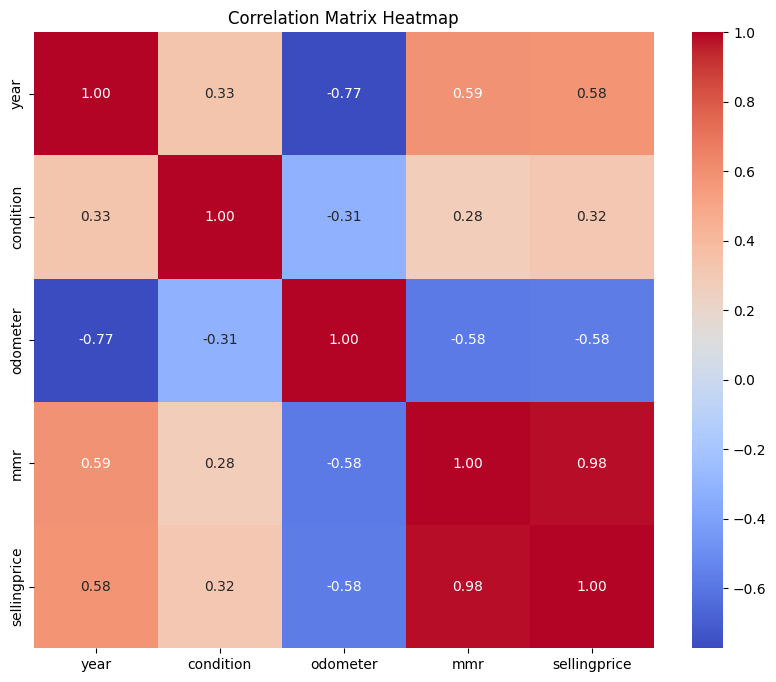

In [65]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Select only numerical columns
numerical_df = df.select_dtypes(include=[np.number])

# Calculate the correlation matrix
correlation_matrix = numerical_df.corr()

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix Heatmap')
plt.show()

In [66]:
le= LabelEncoder()
mm=MinMaxScaler()

In [67]:
list_le=df["transmission"]
list_le=le.fit_transform(list_le)

In [68]:
from sklearn.preprocessing import OneHotEncoder

list_on = ["make", "model", "trim", "body", "color", "interior", "seller",'year','state']
on = OneHotEncoder(sparse_output=True, handle_unknown='ignore')  # Use sparse_output=True to save memory
list_on_encoded = on.fit_transform(df[list_on])



In [69]:
list_mm=df[["condition","odometer","mmr"]]
list_mm=mm.fit_transform(list_mm)

In [70]:
# Reshape list_le to have 2 dimensions
list_le_reshaped = list_le.reshape(-1, 1)

# Concatenate the arrays using sparse matrix
from scipy.sparse import hstack

newdata = hstack((list_mm, list_on_encoded, list_le_reshaped))


In [71]:
X = newdata
y = df['sellingprice']

In [72]:
# تقسيم البيانات
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=100)

In [92]:
lr = LinearRegression()
lr.fit(X_train, y_train)

LinearRegression()

In [74]:
#  التنبؤ علي  بيانات التدريب
y_pred_train = lr.predict(X_train)
# التنبؤ على بيانات الاختبار
y_pred_test = lr.predict(X_test)

In [76]:
accuracy = r2_score(y_test, y_pred_test)
print("the accuracy is :",accuracy*100)

the mse is : 2390781.7097804477
the accuracy is : 97.35436502024015


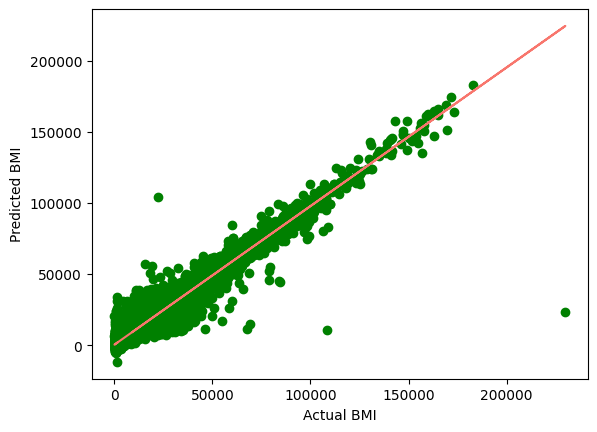

In [78]:
import numpy as np
import matplotlib.pyplot as plt

# Assuming y_train and y_pred_train are your data
# y_train = y_train.flatten()  # Ensure y_train is a 1D array
# y_pred_train = y_pred_train.flatten()  # Ensure y_pred_train is a 1D array

# Plotting the results
plt.scatter(y_train, y_pred_train, alpha=1, color="GREEN")
plt.plot(y_train, np.poly1d(np.polyfit(y_train, y_pred_train, 1))(y_train), color='#F8766D')
plt.xlabel('Actual BMI')
plt.ylabel('Predicted BMI')
plt.show()

In [80]:
import joblib
joblib.dump(mm, 'scaler.pkl')
joblib.dump(on, 'encoder.pkl')
joblib.dump(le, 'le.pkl')
joblib.dump(lr, 'model.pkl')


['scaler.pkl']

In [97]:
import gradio as gr
import joblib
from scipy.sparse import hstack
import numpy as np

# Load the model, scaler, encoder, and label encoder
model = joblib.load('model.pkl')
scaler = joblib.load('scaler.pkl')
encoder = joblib.load('encoder.pkl')
le = joblib.load('le.pkl')  # Assuming label encoder is saved separately

# Function to process input and predict selling price
def process_input(year, make, model_name, trim, body, transmission, state, condition, odometer, color, interior, seller, mmr):
    # Validate inputs
    text_fields = [make, model_name, trim, body, transmission, state, color, interior, seller]
    numeric_fields = [year, condition, odometer, mmr]
    
    # Check if any input is missing
    for idx, value in enumerate(text_fields + numeric_fields):
        if value is None or (isinstance(value, str) and value.strip() == ""):
            field_name = [
                "Year", "Make", "Model", "Trim", "Body", "Transmission", "State", 
                "Condition", "Odometer", "Color", "Interior", "Seller", "MMR"
            ][idx]
            return f"Error: {field_name} is missing or invalid."
    
    # Preprocess inputs
    make, model_name, trim, body, transmission, state, color, interior, seller = [
        field.strip().lower() for field in text_fields
    ]
    
    # Encode categorical features
    list_on = [make, model_name, trim, body, color, interior, seller, year, state]
    list_on_encoded = encoder.transform([list_on])  # Encode using the trained encoder
    
    # Encode transmission using label encoder
    transmission_encoded = le.transform([transmission]).reshape(-1, 1).astype("float64")
    
    # Combine numeric features
    list_mm = np.array([[float(condition), float(odometer), float(mmr)]], dtype="float64")
    list_mm = scaler.transform(list_mm)  # Scale using the trained scaler
    
    # Concatenate all features into a sparse matrix
    newdata = hstack((list_mm, list_on_encoded, transmission_encoded))
    
    # Predict the selling price
    selling_price = model.predict(newdata)
    return f"Predicted Selling Price: ${selling_price[0]:,.2f}"

# Define the Gradio interface
demo = gr.Interface(
    fn=process_input,  # Function to use
    inputs=[
        gr.Textbox(label="Year"),
        gr.Textbox(label="Make"),
        gr.Textbox(label="Model"),
        gr.Textbox(label="Trim"),
        gr.Textbox(label="Body"),
        gr.Textbox(label="Transmission"),
        gr.Textbox(label="State"),
        gr.Textbox(label="Condition (range from 1 to 45)"),
        gr.Textbox(label="Odometer (miles driven)"),
        gr.Textbox(label="Color"),
        gr.Textbox(label="Interior (interior color)"),
        gr.Textbox(label="Seller"),
        gr.Slider(1, 500000, label="MMR (Manufacturer's Suggested Retail Price)"),
    ],
    outputs=gr.Textbox(label="Predicted Selling Price"),
    title="Car Price Prediction",
    description="Enter the car details to predict its selling price."
)

if __name__ == "__main__":
    demo.launch()


Running on local URL:  http://127.0.0.1:7867

To create a public link, set `share=True` in `launch()`.


c:\Users\tahab\fantasy\Lib\site-packages\gradio\analytics.py:106: UserWarning: IMPORTANT: You are using gradio version 4.44.0, however version 4.44.1 is available, please upgrade. 
--------
  warnings.warn(
c:\Users\tahab\fantasy\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but OneHotEncoder was fitted with feature names
  warnings.warn(
c:\Users\tahab\fantasy\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
c:\Users\tahab\fantasy\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but OneHotEncoder was fitted with feature names
  warnings.warn(
c:\Users\tahab\fantasy\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
c:\Users\tahab\fantasy\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not h

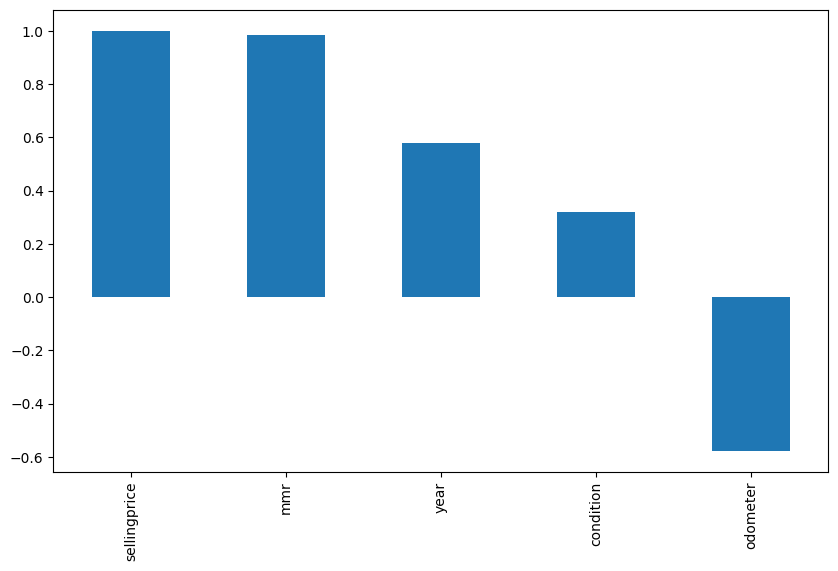

c:\Users\tahab\fantasy\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but OneHotEncoder was fitted with feature names
  warnings.warn(


[[15214.24867458]]


c:\Users\tahab\fantasy\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but OneHotEncoder was fitted with feature names
  warnings.warn(


[[15438.97609909]]


c:\Users\tahab\fantasy\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but OneHotEncoder was fitted with feature names
  warnings.warn(


...

[[15438.97738629]]


c:\Users\tahab\fantasy\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but OneHotEncoder was fitted with feature names
  warnings.warn(


[[15438.97738629]]


c:\Users\tahab\fantasy\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but OneHotEncoder was fitted with feature names
  warnings.warn(


[[15500.8854712]]


In [254]:
plt.figure(figsize=(10, 6))
numeric_df = df.select_dtypes(include=['float64', 'int64'])

numeric_df.corr()['sellingprice'].sort_values(ascending=False).plot(kind='bar')
plt.show()

In [335]:
import imaplib
import email
from transformers import BartForConditionalGeneration, BartTokenizer, pipeline

# Load pre-trained model and tokenizer for summarization
model_name = 'facebook/bart-large-cnn'
tokenizer = BartTokenizer.from_pretrained(model_name)
model = BartForConditionalGeneration.from_pretrained(model_name)

# Load sentiment analysis model
sentiment_analyzer = pipeline('sentiment-analysis', model='distilbert-base-uncased')

# Connect to your email account
mail = imaplib.IMAP4_SSL('imap.gmail.com')  # Example for Gmail, adjust accordingly
mail.login('taha.bando66@gmail.com', 'ojyl vdsl boya gwhw')
mail.select('inbox')  # Select the mailbox you want to retrieve emails from

# Function to generate summary
def generate_summary(email_text):
    inputs = tokenizer([email_text], return_tensors='pt', max_length=1024, truncation=True)

    with torch.no_grad():
        summary_ids = model.generate(**inputs)

    summary = tokenizer.decode(summary_ids[0], skip_special_tokens=True)
    return summary

# Search for all emails
status, messages = mail.search(None, 'ALL')
message_ids = messages[0].split()

# Process and summarize the latest 10 emails received today
for msg_id in message_ids[-10:]:
    status, msg_data = mail.fetch(msg_id, '(RFC822)')
    raw_email = msg_data[0][1]
    msg = email.message_from_bytes(raw_email)
    sender = msg['From']
    subject = msg['subject']
    body = ""

    if msg.is_multipart():
        for part in msg.walk():
            if part.get_content_type() == "text/plain":
                body = part.get_payload(decode=True).decode()
                break
    else:
        body = msg.get_payload(decode=True).decode()

    if body:
        summary = generate_summary(body)

        # Perform sentiment analysis on the summary
        sentiment_result = sentiment_analyzer(summary)
        label = sentiment_result[0]['label']
        score = sentiment_result[0]['score']

        print(f"From: {sender}")
        print(f"Email Subject: {subject}")
        print(f"Generated Summary: {summary}")
        print(f"Sentiment: {label}, Score: {score}")
        print("-" * 50)

mail.logout()

c:\Users\tahab\fantasy\Lib\site-packages\huggingface_hub\file_download.py:159: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\tahab\.cache\huggingface\hub\models--distilbert-base-uncased. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to see activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Device set to use cpu


NameError: name 'torch' is not defined